In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
data = pd.read_csv("survey_results_public.csv")
data.head()

,ResponseId,MainBranch,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,...,TimeSearching,TimeAnswering,Onboarding,ProfessionalTech,TrueFalse_1,TrueFalse_2,TrueFalse_3,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,None of these,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,"Employed, full-time",Fully remote,Hobby;Contribute to open-source projects,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Difficult,NaN
2,3,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Friend or family member...,Technical documentation;Blogs;Programming Game...,NaN,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,40205.0
3,4,I am a developer by profession,"Employed, full-time",Fully remote,I don’t code outside of work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Books / Physical media;School (i.e., Universit...",NaN,NaN,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,215232.0
4,5,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Stack Overflow;O...,NaN,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN


In [30]:
data.shape

(73268, 79)

In [31]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73268 entries, 0 to 73267
Data columns (total 79 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ResponseId                      73268 non-null  int64  
 1   MainBranch                      73268 non-null  object 
 2   Employment                      71709 non-null  object 
 3   RemoteWork                      58958 non-null  object 
 4   CodingActivities                58899 non-null  object 
 5   EdLevel                         71571 non-null  object 
 6   LearnCode                       71580 non-null  object 
 7   LearnCodeOnline                 50685 non-null  object 
 8   LearnCodeCoursesCert            29389 non-null  object 
 9   YearsCode                       71331 non-null  object 
 10  YearsCodePro                    51833 non-null  object 
 11  DevType                         61302 non-null  object 
 12  OrgSize                         

In [32]:
data.columns

Index(['ResponseId', 'MainBranch', 'Employment', 'RemoteWork',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       'LearnCodeCoursesCert', 'YearsCode', 'YearsCodePro', 'DevType',
       'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'Country', 'Currency',
       'CompTotal', 'CompFreq', 'LanguageHaveWorkedWith',
       'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith',
       'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith',
       'PlatformWantToWorkWith', 'WebframeHaveWorkedWith',
       'WebframeWantToWorkWith', 'MiscTechHaveWorkedWith',
       'MiscTechWantToWorkWith', 'ToolsTechHaveWorkedWith',
       'ToolsTechWantToWorkWith', 'NEWCollabToolsHaveWorkedWith',
       'NEWCollabToolsWantToWorkWith', 'OpSysProfessional use',
       'OpSysPersonal use', 'VersionControlSystem', 'VCInteraction',
       'VCHostingPersonal use', 'VCHostingProfessional use',
       'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',
       'OfficeStackSyncHaveWork

In [33]:
df1 = data[["EdLevel","YearsCodePro","Employment","ConvertedCompYearly","Country"]]
df1

,EdLevel,YearsCodePro,Employment,ConvertedCompYearly,Country
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,"Employed, full-time",NaN,Canada
2,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,"Employed, full-time",40205.0,United Kingdom of Great Britain and Northern I...
3,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,"Employed, full-time",215232.0,Israel
4,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",3,"Employed, full-time",NaN,United States of America
...,...,...,...,...,...
73263,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5,"Employed, full-time",NaN,Nigeria
73264,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,"Employed, full-time",NaN,United States of America
73265,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",33,"Employed, full-time",NaN,United States of America
73266,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",31,"Employed, full-time",NaN,United Kingdom of Great Britain and Northern I...


In [34]:
df1 = df1.rename({"ConvertedCompYearly":"Salary"},axis=1)
df1

,EdLevel,YearsCodePro,Employment,Salary,Country
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,"Employed, full-time",NaN,Canada
2,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,"Employed, full-time",40205.0,United Kingdom of Great Britain and Northern I...
3,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,"Employed, full-time",215232.0,Israel
4,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",3,"Employed, full-time",NaN,United States of America
...,...,...,...,...,...
73263,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5,"Employed, full-time",NaN,Nigeria
73264,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,"Employed, full-time",NaN,United States of America
73265,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",33,"Employed, full-time",NaN,United States of America
73266,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",31,"Employed, full-time",NaN,United Kingdom of Great Britain and Northern I...


In [35]:
df1.columns

Index(['EdLevel', 'YearsCodePro', 'Employment', 'Salary', 'Country'], dtype='object')

In [36]:
df1.isnull().sum()

EdLevel          1697
YearsCodePro    21435
Employment       1559
Salary          35197
Country          1497
dtype: int64

In [37]:
df1 = df1[df1["Salary"].notnull()]
df1


,EdLevel,YearsCodePro,Employment,Salary,Country
2,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,"Employed, full-time",40205.0,United Kingdom of Great Britain and Northern I...
3,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,"Employed, full-time",215232.0,Israel
8,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",6,"Employed, full-time",49056.0,Netherlands
10,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,"Employed, full-time",60307.0,United Kingdom of Great Britain and Northern I...
11,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",10,"Employed, full-time;Independent contractor, fr...",194400.0,United States of America
...,...,...,...,...,...
73116,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",16,"Employed, full-time",115000.0,United States of America
73118,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",3,"Employed, full-time",57720.0,Nigeria
73119,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",1,"Employed, full-time",70000.0,United States of America
73120,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,"Employed, full-time",35192.0,Spain


In [38]:
df1 = df1.dropna()
df1

,EdLevel,YearsCodePro,Employment,Salary,Country
2,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,"Employed, full-time",40205.0,United Kingdom of Great Britain and Northern I...
3,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,"Employed, full-time",215232.0,Israel
8,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",6,"Employed, full-time",49056.0,Netherlands
10,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,"Employed, full-time",60307.0,United Kingdom of Great Britain and Northern I...
11,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",10,"Employed, full-time;Independent contractor, fr...",194400.0,United States of America
...,...,...,...,...,...
73116,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",16,"Employed, full-time",115000.0,United States of America
73118,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",3,"Employed, full-time",57720.0,Nigeria
73119,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",1,"Employed, full-time",70000.0,United States of America
73120,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,"Employed, full-time",35192.0,Spain


In [39]:
df1.isnull().sum()

EdLevel         0
YearsCodePro    0
Employment      0
Salary          0
Country         0
dtype: int64

In [40]:
df1[["Employment"]].value_counts()

Employment                                                                                  
Employed, full-time                                                                             31382
Independent contractor, freelancer, or self-employed                                             2739
Employed, full-time;Independent contractor, freelancer, or self-employed                         2633
Employed, part-time                                                                               632
Independent contractor, freelancer, or self-employed;Employed, part-time                          207
Employed, full-time;Employed, part-time                                                           151
Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time      118
I prefer not to say                                                                                27
Retired                                                                                    

In [41]:
shaped = df1[df1["Employment"]=="Employed, full-time"]
shaped.shape

(31382, 5)

In [42]:
df1[["Country"]].value_counts()

Country                                             
United States of America                                8684
Germany                                                 2901
United Kingdom of Great Britain and Northern Ireland    2649
India                                                   2154
Canada                                                  1478
                                                        ... 
Palau                                                      1
Somalia                                                    1
Seychelles                                                 1
Saint Lucia                                                1
Suriname                                                   1
Name: count, Length: 159, dtype: int64

In [43]:
df1=shaped.drop("Employment",axis=1)

In [44]:
df1

,EdLevel,YearsCodePro,Salary,Country
2,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,40205.0,United Kingdom of Great Britain and Northern I...
3,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,215232.0,Israel
8,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",6,49056.0,Netherlands
10,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,60307.0,United Kingdom of Great Britain and Northern I...
12,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5,65000.0,United States of America
...,...,...,...,...
73116,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",16,115000.0,United States of America
73118,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",3,57720.0,Nigeria
73119,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",1,70000.0,United States of America
73120,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,35192.0,Spain


In [45]:
df1["Country"].unique()

array(['United Kingdom of Great Britain and Northern Ireland', 'Israel',
       'Netherlands', 'United States of America', 'Czech Republic',
       'Austria', 'Italy', 'Canada', 'Germany', 'Madagascar', 'Poland',
       'Norway', 'Taiwan', 'France', 'Brazil', 'Uruguay', 'Sweden',
       'Spain', 'Turkey', 'Singapore', 'India', 'Belgium', 'Bulgaria',
       'Ireland', 'Greece', 'Portugal', 'Saudi Arabia', 'Mexico',
       'Switzerland', 'Latvia', 'South Africa', 'Thailand', 'China',
       'Montenegro', 'Finland', 'Slovakia', 'Denmark', 'Australia',
       'Viet Nam', 'Argentina', 'Hungary', 'Tunisia', 'Bangladesh',
       'Ukraine', 'Maldives', 'Hong Kong (S.A.R.)', 'Romania', 'Serbia',
       'Pakistan', 'Nepal', 'Russian Federation', 'Croatia',
       'Bosnia and Herzegovina', 'Lithuania',
       'Iran, Islamic Republic of...', 'Belarus', 'Costa Rica',
       'Mauritius', 'Estonia', 'Kazakhstan', 'Morocco', 'Philippines',
       'Chile', 'New Zealand', 'Slovenia', 'Ecuador', 'Japan',

In [46]:
df1[["Country"]].value_counts()

Country                                             
United States of America                                7858
Germany                                                 2382
United Kingdom of Great Britain and Northern Ireland    2341
India                                                   1869
Canada                                                  1249
                                                        ... 
Palau                                                      1
Trinidad and Tobago                                        1
Suriname                                                   1
Yemen                                                      1
Zambia                                                     1
Name: count, Length: 155, dtype: int64

In [47]:
def digest_categories(categories, cutoff):
    categoricalMap = {}
    for i in range(len(categories)):
        if categories.values[i] >= cutoff:
            categoricalMap[categories.index[i]] = categories.index[i]
        else:
            categoricalMap[categories.index[i]] = 'Other'
    return categoricalMap

In [48]:
countryMap = digest_categories(df1.Country.value_counts(), 400)
print(countryMap)


{'United States of America': 'United States of America', 'Germany': 'Germany', 'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom of Great Britain and Northern Ireland', 'India': 'India', 'Canada': 'Canada', 'France': 'France', 'Brazil': 'Brazil', 'Spain': 'Spain', 'Netherlands': 'Netherlands', 'Australia': 'Australia', 'Italy': 'Italy', 'Poland': 'Poland', 'Sweden': 'Sweden', 'Russian Federation': 'Russian Federation', 'Switzerland': 'Switzerland', 'Turkey': 'Other', 'Israel': 'Other', 'Austria': 'Other', 'Norway': 'Other', 'Portugal': 'Other', 'Denmark': 'Other', 'Belgium': 'Other', 'Finland': 'Other', 'Mexico': 'Other', 'New Zealand': 'Other', 'Greece': 'Other', 'South Africa': 'Other', 'Pakistan': 'Other', 'Czech Republic': 'Other', 'Iran, Islamic Republic of...': 'Other', 'Argentina': 'Other', 'Romania': 'Other', 'Ireland': 'Other', 'Ukraine': 'Other', 'Hungary': 'Other', 'Japan': 'Other', 'Bangladesh': 'Other', 'Colombia': 'Other', 'China': 'Other', 'Bulgaria

In [49]:
df1.Country = df1['Country'].map(countryMap)

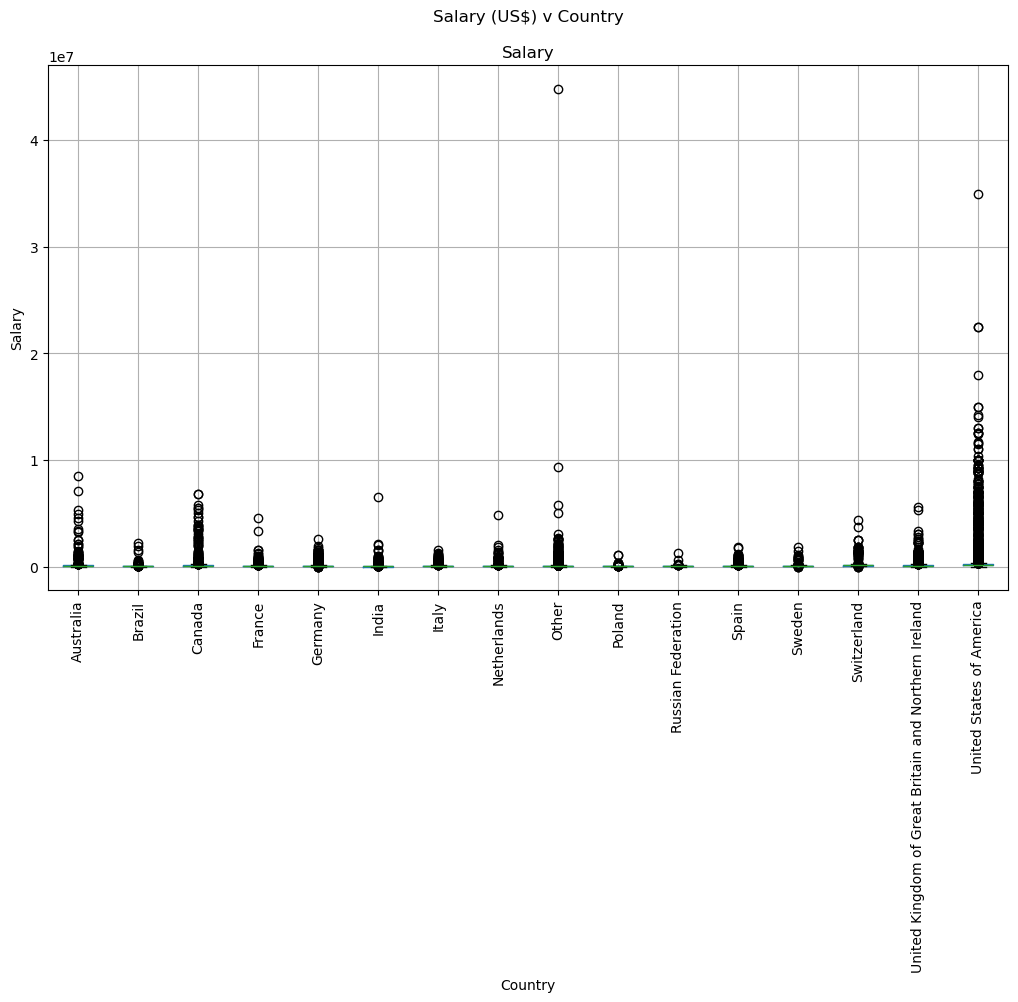

In [50]:
fig,ax = plt.subplots(1,1,figsize=(12,7))
df1.boxplot('Salary', 'Country', ax=ax)
plt.suptitle('Salary (US$) v Country')
plt.ylabel('Salary')
plt.xticks(rotation=90)
plt.show()

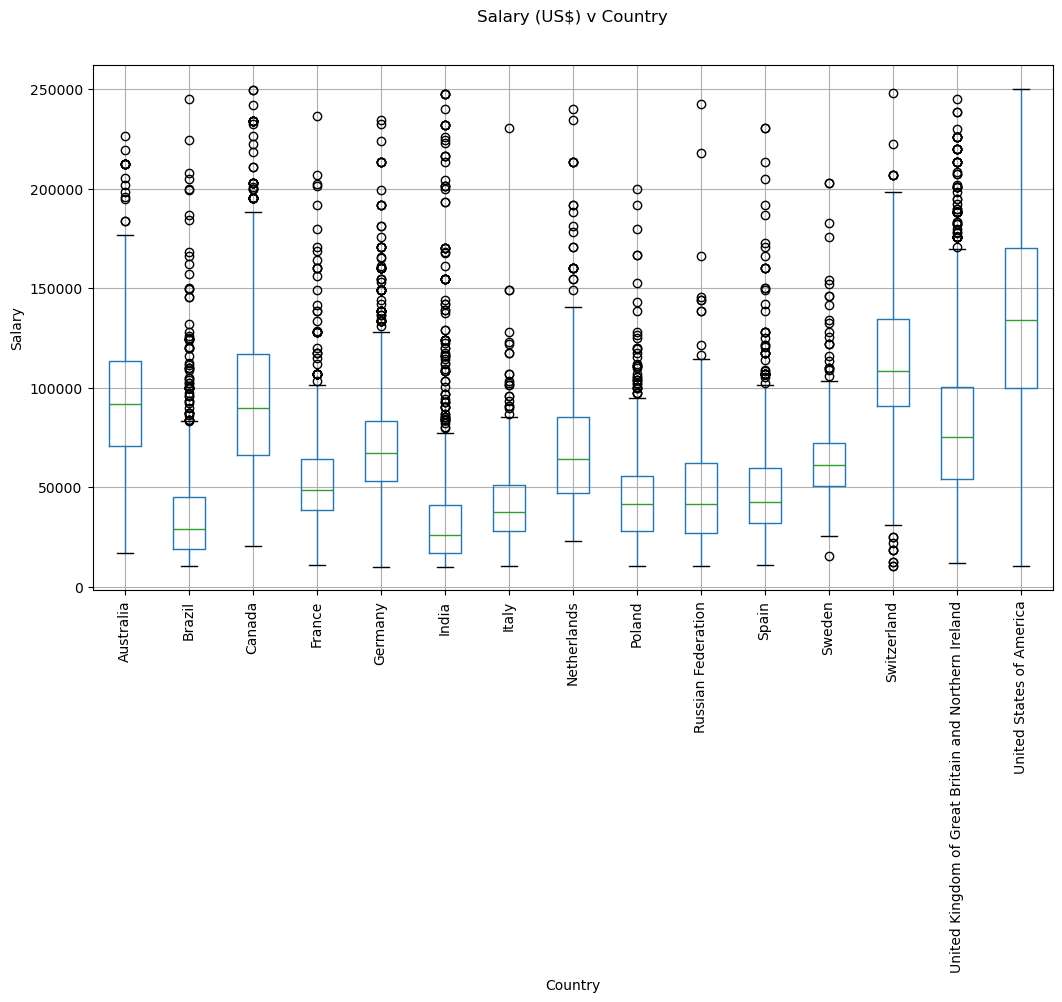

In [51]:
df1 = df1[df1['Salary'] <= 250000]
df1 = df1[df1['Salary'] > 10000]
df1 = df1[df1['Country'] != 'Other']
 
fig, ax = plt.subplots(1,1, figsize=(12,7))
df1.boxplot('Salary', 'Country', ax=ax)
plt.suptitle('Salary (US$) v Country')
plt.title('')
plt.ylabel('Salary')
plt.xticks(rotation=90)
plt.show()

# df1.head()

In [52]:
data.head()

,ResponseId,MainBranch,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,...,TimeSearching,TimeAnswering,Onboarding,ProfessionalTech,TrueFalse_1,TrueFalse_2,TrueFalse_3,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,None of these,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,"Employed, full-time",Fully remote,Hobby;Contribute to open-source projects,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Difficult,NaN
2,3,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Friend or family member...,Technical documentation;Blogs;Programming Game...,NaN,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,40205.0
3,4,I am a developer by profession,"Employed, full-time",Fully remote,I don’t code outside of work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Books / Physical media;School (i.e., Universit...",NaN,NaN,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,215232.0
4,5,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Stack Overflow;O...,NaN,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN


In [53]:
df1["YearsCodePro"].unique()

array(['5', '6', '2', '4', '20', '9', '14', '21', '15', '25', '3', '10',
       '8', '12', '7', '19', '17', '24', '1', '11', '23',
       'Less than 1 year', '18', '37', '46', '22', '32', '13', '27', '28',
       '16', '31', '34', '35', '26', '42', '38', '30', '36', '40', '41',
       '29', '33', '39', '48', '45', '44', '43', 'More than 50 years',
       '47', '49', '50'], dtype=object)

In [54]:
def set_Experience(i):
    if i == "More than 50 years":
        return 50
    if i == "Less than 1 year":
        return 0.5
    return float(i)

In [55]:
df1["YearsCodePro"] = df1["YearsCodePro"].apply(set_Experience)

In [56]:
df1["YearsCodePro"].unique()

array([ 5. ,  6. ,  2. ,  4. , 20. ,  9. , 14. , 21. , 15. , 25. ,  3. ,
       10. ,  8. , 12. ,  7. , 19. , 17. , 24. ,  1. , 11. , 23. ,  0.5,
       18. , 37. , 46. , 22. , 32. , 13. , 27. , 28. , 16. , 31. , 34. ,
       35. , 26. , 42. , 38. , 30. , 36. , 40. , 41. , 29. , 33. , 39. ,
       48. , 45. , 44. , 43. , 50. , 47. , 49. ])

In [57]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19883 entries, 2 to 73121
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EdLevel       19883 non-null  object 
 1   YearsCodePro  19883 non-null  float64
 2   Salary        19883 non-null  float64
 3   Country       19883 non-null  object 
dtypes: float64(2), object(2)
memory usage: 776.7+ KB


In [58]:
df1.columns

Index(['EdLevel', 'YearsCodePro', 'Salary', 'Country'], dtype='object')

In [59]:
df1["EdLevel"].unique()

array(['Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)', 'Something else',
       'Associate degree (A.A., A.S., etc.)',
       'Some college/university study without earning a degree',
       'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
       'Professional degree (JD, MD, etc.)',
       'Other doctoral degree (Ph.D., Ed.D., etc.)',
       'Primary/elementary school'], dtype=object)

In [60]:
def set_education(i):
    if pd.isna(i):
        return "Unknown"

    if "Master’s degree" in i:
        return "Master’s degree"
    elif "Bachelor’s degree" in i:
        return "Bachelor’s degree"
    elif "Professional degree" in i or "Other doctoral degree" in i:
        return "Post grad"
    else:
        return "Less than a Bachelors"

df1["EdLevel"] = df1["EdLevel"].apply(set_education)

In [61]:
df1["EdLevel"] = df1["EdLevel"].apply(set_education)

In [62]:
df1["EdLevel"].unique()

array(['Master’s degree', 'Bachelor’s degree', 'Less than a Bachelors'],
      dtype=object)

In [63]:
from sklearn.preprocessing import LabelEncoder

In [105]:
le_education = LabelEncoder()
df1["EdLevel"] = le_education.fit_transform(df1["EdLevel"])




In [151]:
df1["EdLevel"].unique()

array([2, 0, 1])

In [152]:
df1["Country"].unique()

array([13,  7, 14,  6,  2,  4,  8,  3,  1, 11, 10,  5, 12,  0,  9])

In [153]:
le_Country = LabelEncoder()
df1["Country"] = le_Country.fit_transform(df1["Country"])




In [154]:
df1["Country"].unique()

array([13,  7, 14,  6,  2,  4,  8,  3,  1, 11, 10,  5, 12,  0,  9])

## preparation of data to feed to the model

In [110]:
X=df1.drop("Salary",axis =1)
y = df1["Salary"]

### MODEL BUILDING

In [111]:
from sklearn.linear_model import LinearRegression

In [112]:
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [113]:
y_pred = model.predict(X)

In [114]:
print(y_pred)

[100029.2927175   72323.44269354  96932.59109727 ...  99974.41169497
  82134.17344151  96247.32214239]


In [115]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [116]:
error_right = np.sqrt(mean_squared_error(y,y_pred))

In [117]:
print(error_right)

44693.03896539832


# TRYING DIFFERENT ALGORITHMS

In [118]:
#Decision Tree 

In [119]:
from sklearn.tree import DecisionTreeRegressor

In [164]:
model_dt = DecisionTreeRegressor(random_state = 42)
model_dt.fit(X,y)

DecisionTreeRegressor(random_state=42)

In [165]:
y_pred2 = model_dt.predict(X)

In [166]:
print(y_pred2)

[83773.04761905 64753.5        51430.40298507 ... 94428.45360825
 43848.08333333 64863.94736842]


In [167]:
error_right = np.sqrt(mean_squared_error(y,y_pred2))

In [168]:
print(error_right)

33913.06857391931


## RANDOM FOREST

In [169]:
from sklearn.ensemble import RandomForestRegressor

In [126]:
model_ft =  RandomForestRegressor(random_state = 42)
model_ft.fit(X,y) 

RandomForestRegressor(random_state=42)

In [159]:
y_pred1 = model_ft.predict(X)

In [160]:
print(y_pred1)

[83554.91376571 64344.40619742 51639.39460572 ... 94394.40427907
 42769.77798295 64629.72838242]


In [161]:
error_right = np.sqrt(mean_squared_error(y,y_pred1))

In [162]:
print(error_right)

33963.22473777527


In [131]:
X


,EdLevel,YearsCodePro,Country
2,2,5.0,13
8,2,6.0,7
10,0,2.0,13
12,0,5.0,14
21,2,4.0,6
...,...,...,...
73113,2,5.0,14
73116,0,16.0,14
73119,0,1.0,14
73120,0,2.0,10


In [144]:
p = np.array([["Germany","Masters's degree",4]])
p

array([['Germany', "Masters's degree", '4']], dtype='<U21')

In [145]:

from sklearn.preprocessing import LabelEncoder

In [147]:
p[:,0]=le_Country.fit_transform(p[:,0])
p[:,1]=le_education.fit_transform(p[:,1])
p=p.astype(float)

In [148]:
p

array([[0., 0., 4.]])

In [170]:
y_pred = model_dt.predict(p)
y_pred

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([49727.8])

In [171]:
y_pred = model_dt.predict(p)
y_pred

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([49727.8])

In [157]:
y_pred1 = model_ft.predict(p)
y_pred1

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([49772.38420324])

### Model Saving

In [178]:
data = {'model':model_dt,'le_Country':le_Country,'le_education':le_education}

In [179]:
import pickle

In [180]:
with open('saveModel.pkl', 'wb') as file:
    pickle.dump(data,file)

In [181]:
with open('saveModel.pkl', 'rb') as out:
          data = pickle.load(out)

In [182]:
model_loaded = data['model']
le_Country = data['le_Country']
le_education = data['le_education']

In [188]:
y_predict = model_loaded.predict(p)
y_predict


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([49727.8])